# Colorectal Histology 1
Vou seguir o mesmo padrão do MNIST, mas com histologia colorretal. O colorectal_histology é um dataset de imagens de Classificação de texturas na histologia do câncer colorretal. Cada exemplo é uma imagem RGB de 150 x 150 x 3 de uma das 8 classes. Eu encontrei no catalogo de datasets do tensorflow, anteriormente, eu ia fazer com o Fashion-MNIST, mas achei esse de agora mais legal.  
<small>**OBS:** É necessário baixar tensorflow-datasets (`pip install tensorflow-datasets`).  
Site: <https://www.tensorflow.org/datasets/catalog/colorectal_histology></small>

## Importando as bibliotecas

In [1]:
!pip install tensorflow-datasets tensorflow

In [2]:
import tensorflow as tf
import keras
import matplotlib
import numpy as np

import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
# O dataset não vem dividido, então vou pegar ele e depois fazer a divisão
dataset = tfds.load('colorectal_histology', split = 'train', as_supervised = True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.5MXRJ8_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.


In [4]:
# Ele tem o tamanho de 5.000 imagens pelo que eu vi no site do tensorflow
# Tambem, ele vem em uma tupla (imagem, label), vou extrair as imagens e labels em arrays separados
# depois usar o train_test_split para separar a divisão para treino e teste
imagens = np.array([img.numpy() for img, label in dataset])
labels = np.array([label.numpy() for img, label in dataset])

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    # Divisao de 80/20, sendo 80% para treino e 20% para teste
    imagens, labels, test_size = 0.2, random_state = 42
)

In [6]:
# Diferente da aula, nao vou precisar usar o reshape
X_treino = X_treino.astype('float32')
X_teste = X_teste.astype('float32')

In [7]:
# Agora vou normalizar eles
X_treino /= 255
X_teste /= 255
X_treino.max(), X_treino.min()

(np.float32(1.0), np.float32(0.0))

In [8]:
# Vou transformar as saidas para categoricos, no codigo da aula ele usa 10, porque sao 10 classes, no meu caso sao 8 classes
y_treino = np_utils.to_categorical(y_treino, 8)
y_teste = np_utils.to_categorical(y_teste, 8)
y_treino

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [9]:
y_treino[2]

array([0., 1., 0., 0., 0., 0., 0., 0.])

In [10]:
X_treino.shape, X_teste.shape

((4000, 150, 150, 3), (1000, 150, 150, 3))

Text(0.5, 1.0, 'Classe [0. 1. 0. 0. 0. 0. 0. 0.]')

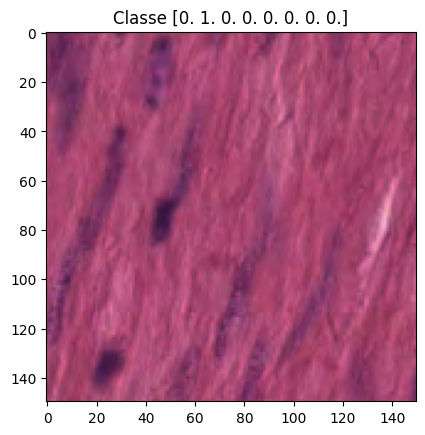

In [11]:
plt.imshow(X_treino[0])
plt.title('Classe ' + str(y_treino[0]))

In [12]:
# Agora que tem os dados prontos, vou começar montar minha rede neural,
rede_neural = Sequential()

rede_neural.add(InputLayer(shape =(150, 150, 3)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Flatten())

rede_neural.add(Dense(units = 128, activation = 'relu'))
rede_neural.add(Dropout(0.2))
rede_neural.add(Dense(units = 8, activation = 'softmax'))

In [13]:
rede_neural.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,319,976 (20.29 MB)

 Trainable params: 5,319,848 (20.29 MB)

 Non-trainable params: 128 (512.00 B)

In [14]:
# Agora vou compilar a rede neural
# Vou usar a função de perda categorical_crossentropy, o otimizador adam e como métrica vou usar acurácia
rede_neural.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [15]:
# Finalmente, vou realizar o treino dela, vou usar 10 epocas com um batch de tamanho 128
rede_neural.fit(X_treino, y_treino, batch_size = 128,
                epochs = 10, validation_data = (X_teste, y_teste))

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step - accuracy: 0.4830 - loss: 7.7980 - val_accuracy: 0.0960 - val_loss: 6.6453
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6672 - loss: 1.3320 - val_accuracy: 0.1370 - val_loss: 17.7458
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.6665 - loss: 1.3038 - val_accuracy: 0.1950 - val_loss: 29.2880
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.7703 - loss: 0.6876 - val_accuracy: 0.2550 - val_loss: 38.9565
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.7930 - loss: 0.5912 - val_accuracy: 0.1290 - val_loss: 45.7147
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.8235 - loss: 0.4931 - val_accuracy: 0.1290 - val_loss: 53.7125
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.8685 - loss: 0.3536 - val_accuracy: 0.2600 - val_loss: 51.9782
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8938 - loss: 0.3287 - val_accuracy: 0.

In [16]:
resultado = rede_neural.evaluate(X_teste, y_teste)
resultado

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3040 - loss: 38.5091


[38.509071350097656, 0.30399999022483826]